<a href="https://colab.research.google.com/github/ziadm8692-glitch/Data-Analysis-Portfolio/blob/main/Project_Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [ ]:
df=pd.read_csv('/content/netflix_titles.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['director'].fillna('Unknown',inplace=True)
df['cast'].fillna('Unknown',inplace=True)
df['country'].fillna(df['country'].mode()[0],inplace=True)
df['date_added'].fillna(df['date_added'].mode()[0],inplace=True)
df['rating'].fillna(df['rating'].mode()[0],inplace=True)
df['duration'].fillna(df['duration'].mode()[0],inplace=True)

/tmp/ipython-input-1502440096.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown',inplace=True)
/tmp/ipython-input-1502440096.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [ ]:
df['month_added'] = df['date_added'].dt.month

In [ ]:
df['year_added']=df['date_added'].dt.year

In [ ]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


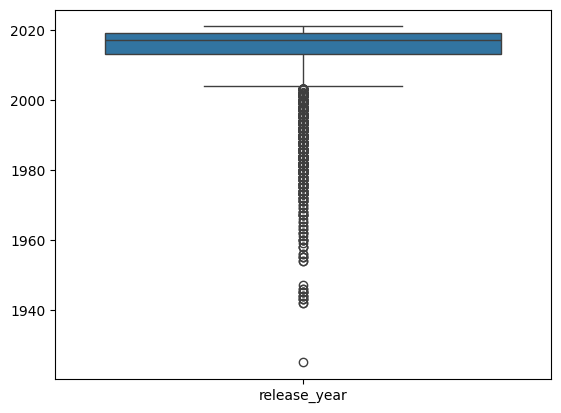

In [ ]:
sns.boxplot(df[['date_added','release_year']])
plt.show()

In [ ]:
Q1=df[['release_year','date_added']].quantile(0.25)
Q3=df[['release_year','date_added']].quantile(0.75)
IQR=Q3-Q1
Lower=Q1-1.5*IQR
Upper=Q3+1.5*IQR
df[['release_year','date_added']]=df[['release_year','date_added']].clip(Lower,Upper,axis=1)

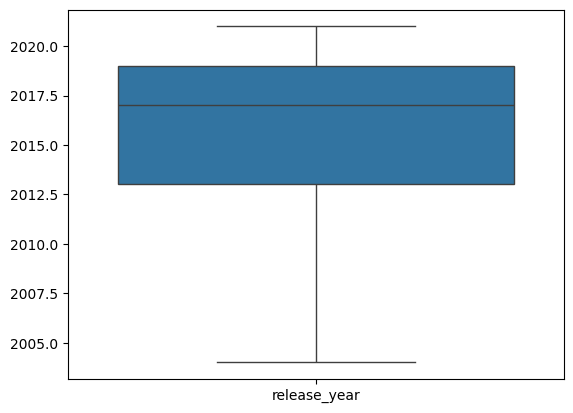

In [ ]:
sns.boxplot(df[['date_added','release_year']])
plt.show()

In [ ]:
df['year_added'] = df['year_added'].fillna(df['year_added'].mode()[0]).astype(int)
df['month_added'] = df['month_added'].fillna(df['month_added'].mode()[0]).astype(int)#>>>>>>>>>>><<<<<>>>>>>>>>>>>>>>>>>>>>>>>><><>,.,.,.,

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,88
release_year,0
rating,0
duration,0


In [ ]:
df[['month_added','year_added']]

,month_added,year_added
0,9,2021
1,9,2021
2,9,2021
3,9,2021
4,9,2021
...,...,...
8802,11,2019
8803,7,2019
8804,11,2019
8805,1,2020


/tmp/ipython-input-2113569677.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='magma')


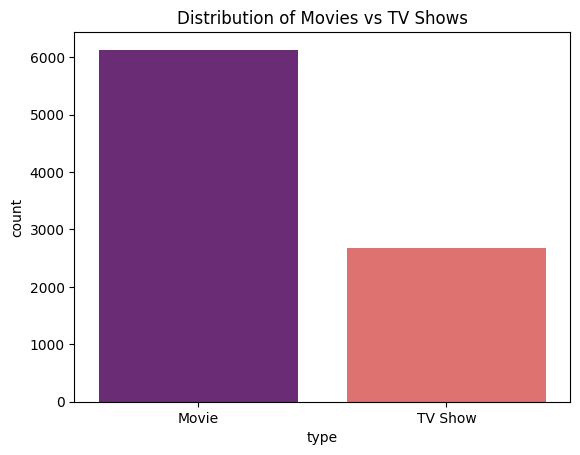

In [ ]:
sns.countplot(x='type', data=df, palette='magma')
plt.title('Distribution of Movies vs TV Shows')
plt.show()

# **Wichtig**

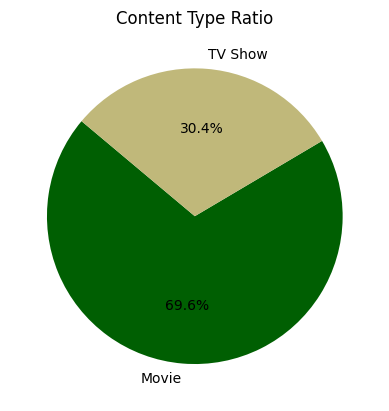

In [ ]:
type_Count=df['type'].value_counts()
plt.pie(type_Count, labels=type_Count.index, autopct='%1.1f%%', startangle=140, colors=['#005F02', '#C0B87A'])
plt.title('Content Type Ratio')
plt.show()

/tmp/ipython-input-3337306934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_gerns.index, y=top_5_gerns.values, palette='magma')


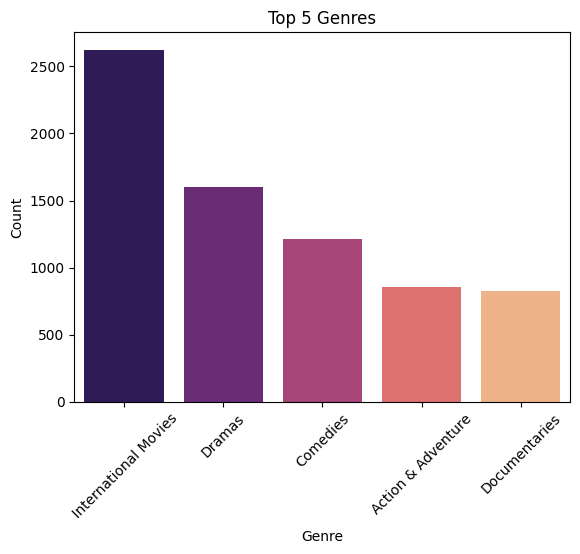

In [ ]:
all_gerns=df['listed_in'].str.split(',').explode()
top_5_gerns=all_gerns.value_counts().head(5)
sns.barplot(x=top_5_gerns.index, y=top_5_gerns.values, palette='magma')
plt.title('Top 5 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

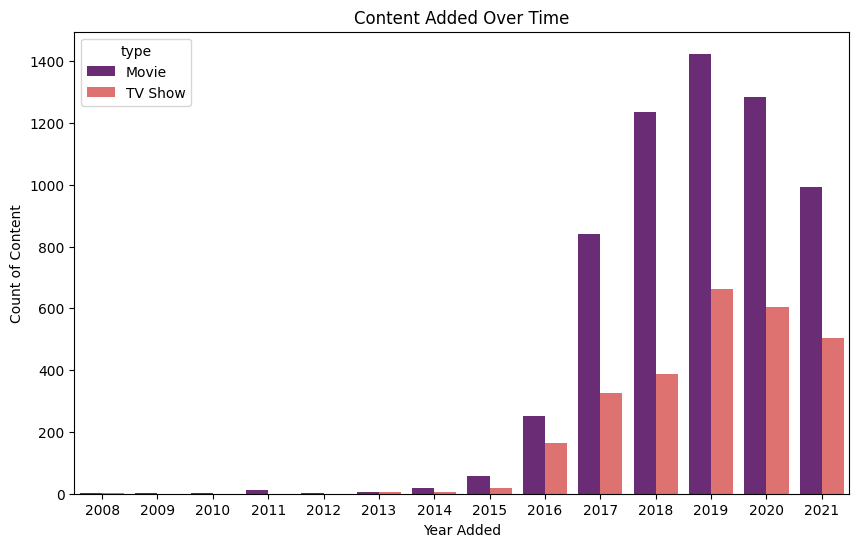

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='year_added', data=df, hue='type', palette='magma')
plt.title('Content Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Count of Content')
plt.show()#>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>.

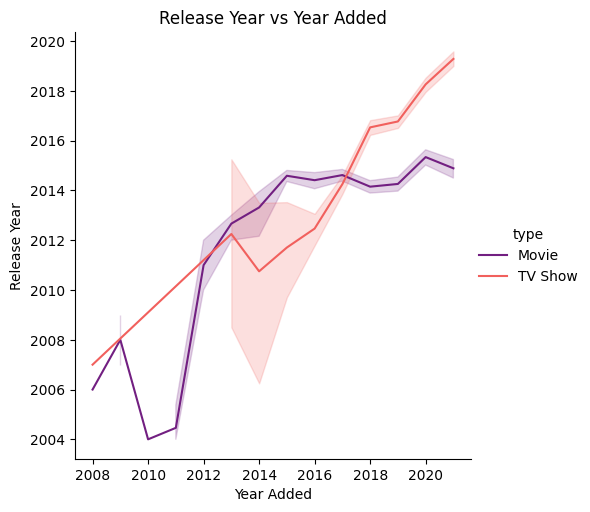

In [ ]:
sns.relplot(x='year_added',y='release_year',data=df,kind='line' ,hue='type', palette='magma')
plt.title('Release Year vs Year Added')
plt.xlabel('Year Added')
plt.ylabel('Release Year')
plt.show()

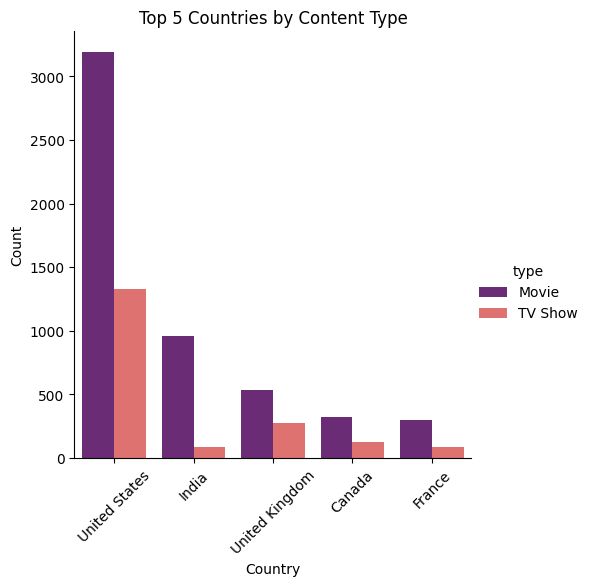

In [ ]:
# Explode the 'country' column to have one row per country, keeping 'type'
exploded_df = df.assign(country_single=df['country'].str.split(',')).explode('country_single')
exploded_df['country_single'] = exploded_df['country_single'].str.strip() # Clean whitespace

# Get the list of top 5 country names (based on overall count) for ordering
top_5_country_names = exploded_df['country_single'].value_counts().head(5).index.tolist()

# Filter the exploded DataFrame to include only these top 5 countries
filtered_top_countries_df = exploded_df[exploded_df['country_single'].isin(top_5_country_names)]

# Now plot with 'country_single' as x, and 'type' as hue, using the filtered DataFrame
sns.catplot(x='country_single', hue='type', data=filtered_top_countries_df, kind='count', palette='magma', order=top_5_country_names)
plt.title('Top 5 Countries by Content Type')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()#<><><>><>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>.

In [ ]:
df['Orgianl']=df['country'].apply(lambda x:'Domestic' if  'United States' in x
                                  else 'international')
origin_counts=df['Orgianl'].value_counts()

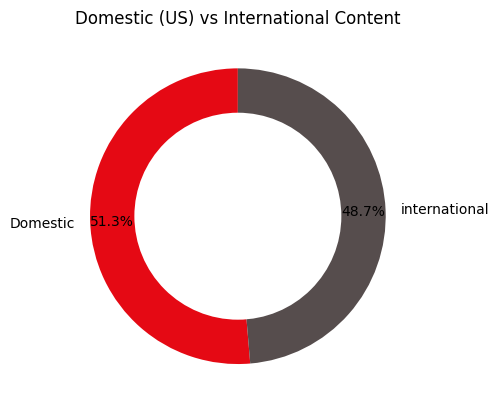

In [ ]:
import matplotlib.pyplot as plt

plt.pie(origin_counts, labels=origin_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#E50914', '#564d4d'], pctdistance=0.85)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Domestic (US) vs International Content')
plt.show()

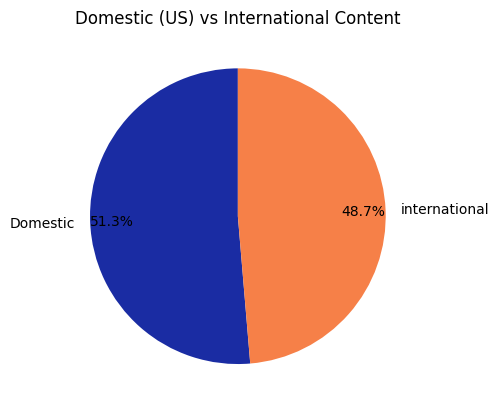

In [ ]:
plt.pie(origin_counts,labels=origin_counts.index,autopct="%1.1f%%",pctdistance=0.85,startangle=90,colors=['#1A2CA3','#F68048'])
plt.title('Domestic (US) vs International Content')
plt.show()

In [ ]:
tv_shows = df[df['type'] == 'TV Show'].assign()
tv_shows['seasons_count'] = tv_shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)
average_seasons = tv_shows['seasons_count'].mean()

/tmp/ipython-input-906457597.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='seasons_count', data=tv_shows, palette='viridis')


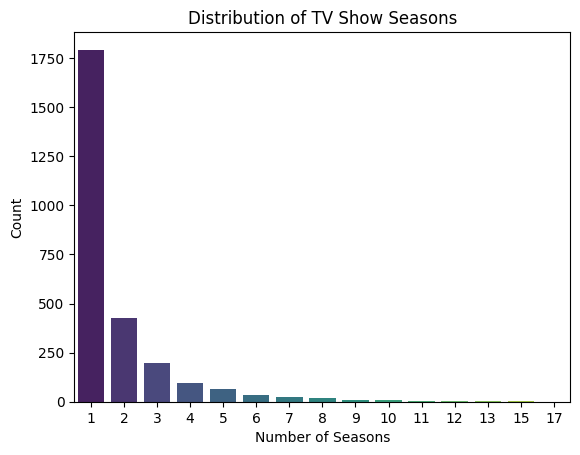

In [ ]:
sns.countplot(x='seasons_count', data=tv_shows, palette='viridis')
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.show()

In [ ]:
movies_df = df[df['type'] == 'Movie'].copy()

movies_df['duration_min'] = pd.to_numeric(movies_df['duration'].str.replace(' min', ''), errors='coerce')

movies_df['duration_min'].fillna(movies_df['duration_min'].mean(), inplace=True)

movies_df['duration_min'] = movies_df['duration_min'].astype(int)

avg_movie_duration = movies_df['duration_min'].mean()

/tmp/ipython-input-3338420170.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies_df['duration_min'].fillna(movies_df['duration_min'].mean(), inplace=True)


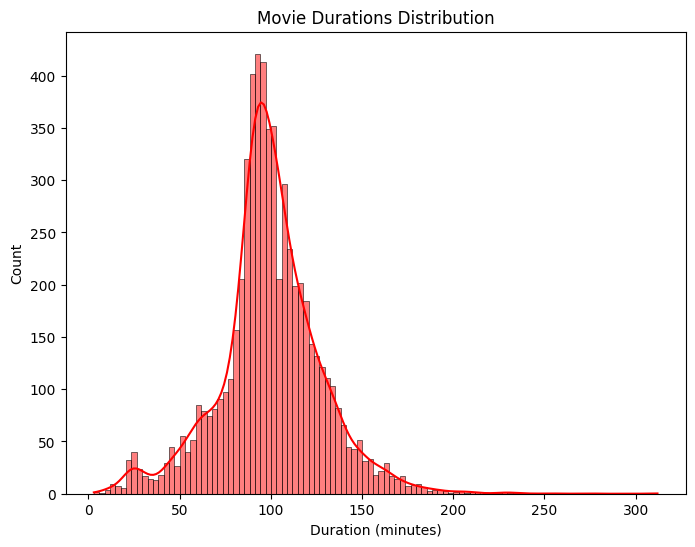

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.histplot(movies_df['duration_min'], kde=True, color='red')
plt.title('Movie Durations Distribution')
plt.xlabel('Duration (minutes)')
plt.show()

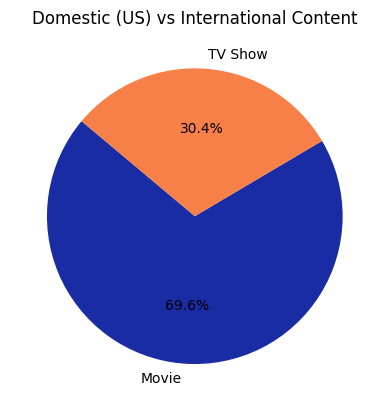

In [ ]:
type_Count=df['type'].value_counts()
plt.pie(type_Count,labels=type_Count.index,autopct="%1.1f%%",startangle=140,colors=['#1A2CA3','#F68048'])
plt.title('Domestic (US) vs International Content')
plt.show()

/tmp/ipython-input-3213995878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=A.index, y=A.values,palette='magma')


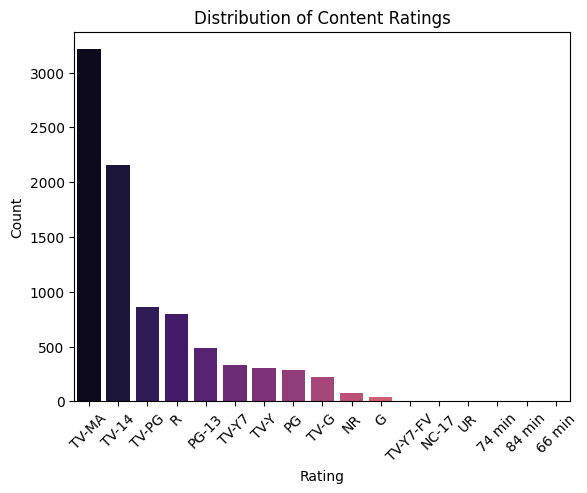

In [ ]:
A =df['rating'].value_counts()
sns.barplot(x=A.index, y=A.values,palette='magma')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

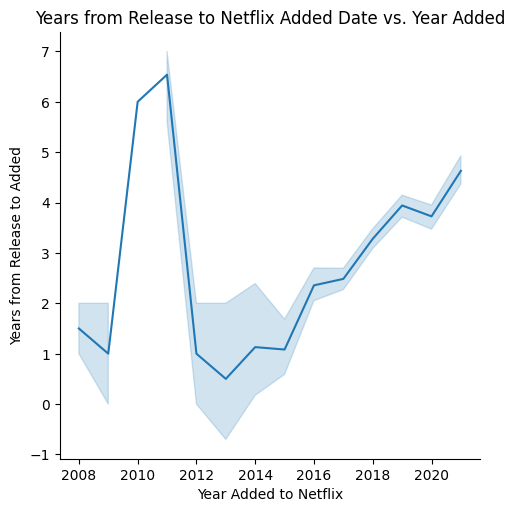

In [ ]:
df['years_to_add'] = df['year_added'] - df['release_year']
sns.relplot(x='year_added', y='years_to_add', data=df,kind='line')
plt.title('Years from Release to Netflix Added Date vs. Year Added')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Years from Release to Added')
plt.show()

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,88
release_year,0
rating,0
duration,0


In [ ]:
df['date_added'].fillna(df['date_added'].mode()[0],inplace=True)

/tmp/ipython-input-41047033.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna(df['date_added'].mode()[0],inplace=True)


In [ ]:
df = df[df['director'] != 'Unknown']

df = df.replace('Unknown', np.nan).dropna()

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


/tmp/ipython-input-1845236244.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=director_count.index,y=director_count.values,palette='magma')


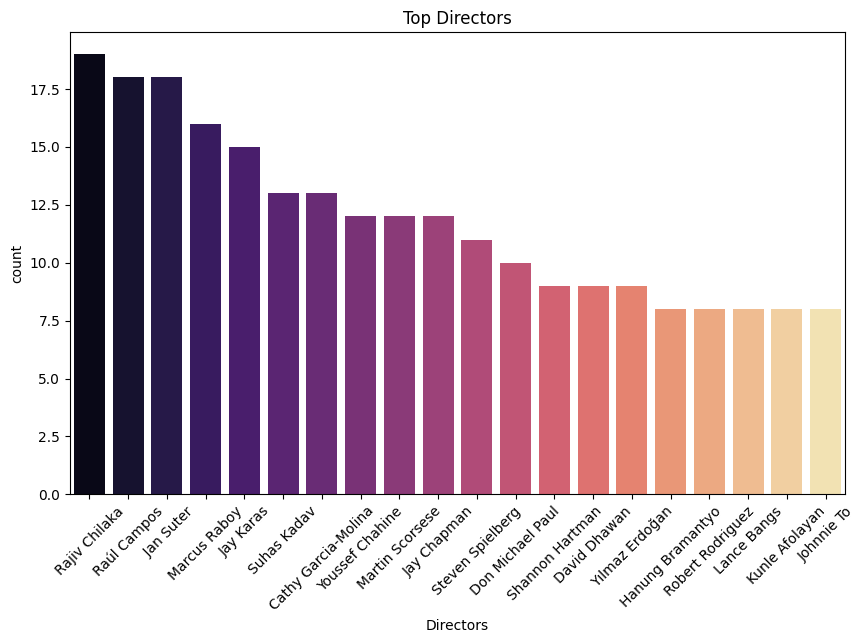

In [ ]:
V_df=df['director'].str.split(',').explode()
director_count=V_df.value_counts().head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=director_count.index,y=director_count.values,palette='magma')
plt.title('Top Directors')
plt.xlabel('Directors')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()


In [ ]:
df['cast']

,cast
2,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
5,"Kate Siegel, Zach Gilford, Hamish Linklater, H..."
6,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ..."
7,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D..."
8,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho..."
...,...
8801,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ..."
8802,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J..."
8804,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ..."
8805,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma..."


/tmp/ipython-input-3028981101.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Cast_count.index,y=Cast_count.values,palette='magma')


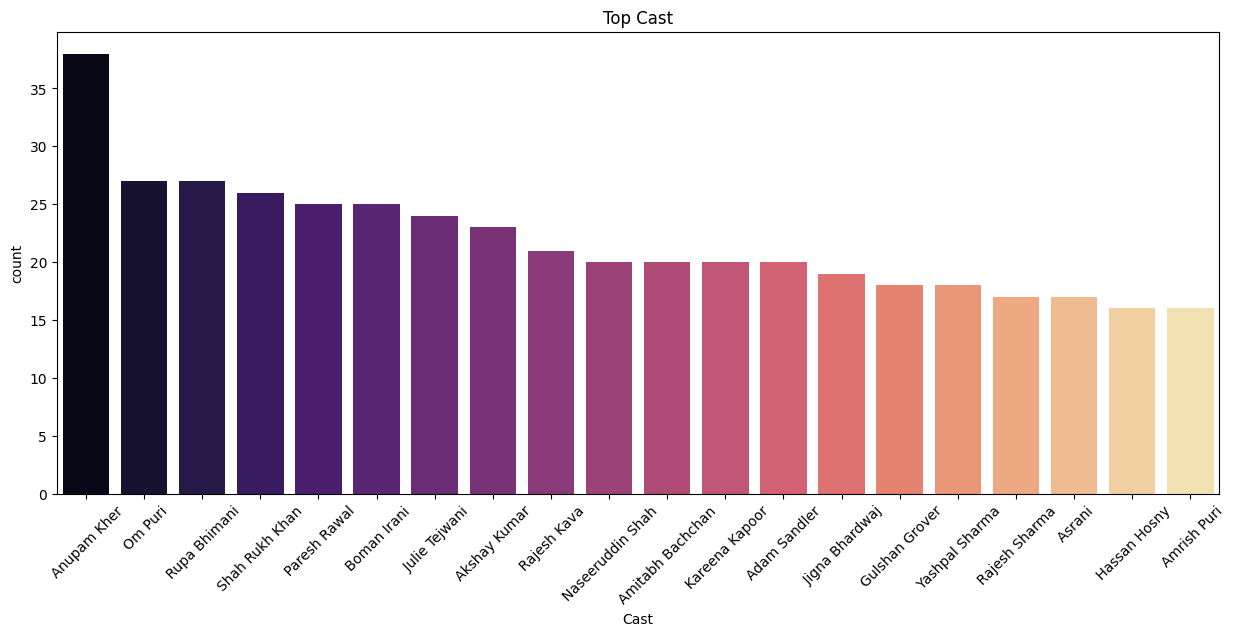

In [ ]:
Cast_p=df['cast'].str.split(',').explode()
Cast_count=Cast_p.value_counts().head(20)
plt.figure(figsize=(15, 6))
sns.barplot(x=Cast_count.index,y=Cast_count.values,palette='magma')
plt.title('Top Cast')
plt.xlabel('Cast')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
le = LabelEncoder()
for col in ['Orgianl', 'country', 'rating','type']:
    df[col] = le.fit_transform(df[col])

In [ ]:
unwanted_columns = ['show_id', 'type', 'title', 'description', 'director', 'cast', 'date_added', 'listed_in', 'duration']
x = df.drop(unwanted_columns, axis=1)
y = df['type']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
rf=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10,class_weight='balanced')
rf.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [ ]:
y_pred=rf.predict(x_test)

In [ ]:
# هنعمل جدول (DataFrame) يجمع الحقيقة بالتوقع
results = pd.DataFrame({
    'Actual (Y_test)': y_test,
    'Predicted (y_pred)': y_pred
})

# نعرض أول 10 صفوف بس عشان نشوفهم بوضوح
print(results.head(10))

      Actual (Y_test)  Predicted (y_pred)
2289                0                   0
1172                0                   0
7271                0                   0
2310                0                   0
4205                0                   0
1491                0                   1
2522                1                   1
2625                0                   1
4343                0                   0
7916                0                   0


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1094
           1       0.13      0.24      0.17        46

    accuracy                           0.90      1140
   macro avg       0.55      0.58      0.56      1140
weighted avg       0.93      0.90      0.92      1140



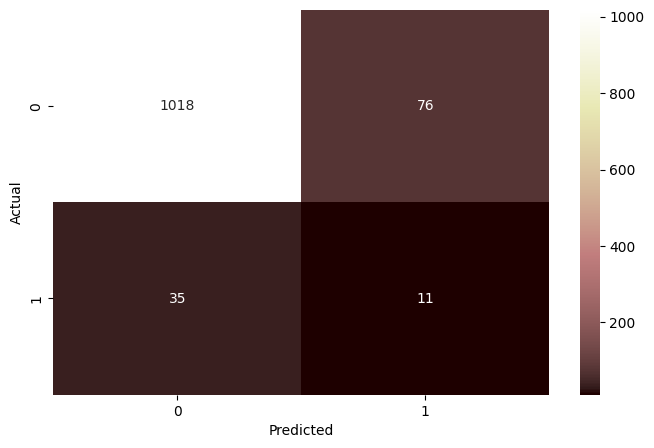

In [ ]:
co=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,5))
sns.heatmap(co,annot=True,fmt='d',cmap='pink')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
